# My Makemore #

First we'll open the names file and store the words into a collection.

In [31]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [1]:
words = open('names.txt', 'r').read().splitlines()

## Bigram Model ##

Bigram models are good to start, we iterate by two consecutive characters in each word.

In [15]:
b = {}
for w in words:
    # Special characters to mark the start and end of words
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        # We count the number of times a combination of characters occurs
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [16]:
import torch

We'll create a 2D array to store this info using pytorch.

The array will be 27 x 27 as we're indexing by two letters of the alphabet (26 x 26) and the special character (1)

In [36]:
N = torch.zeros((27,27), dtype=torch.int32)

Now we copy the code above but index into the array using integers.

In [39]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
# Inverse of stoi to make the figure look nicer
itos = {i:s for s, i in stoi.items()}

In [40]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        N[idx1, idx2] += 1

N can be visualized nicely using matplotlib

(np.float64(-0.5), np.float64(26.5), np.float64(27.5), np.float64(-0.5))

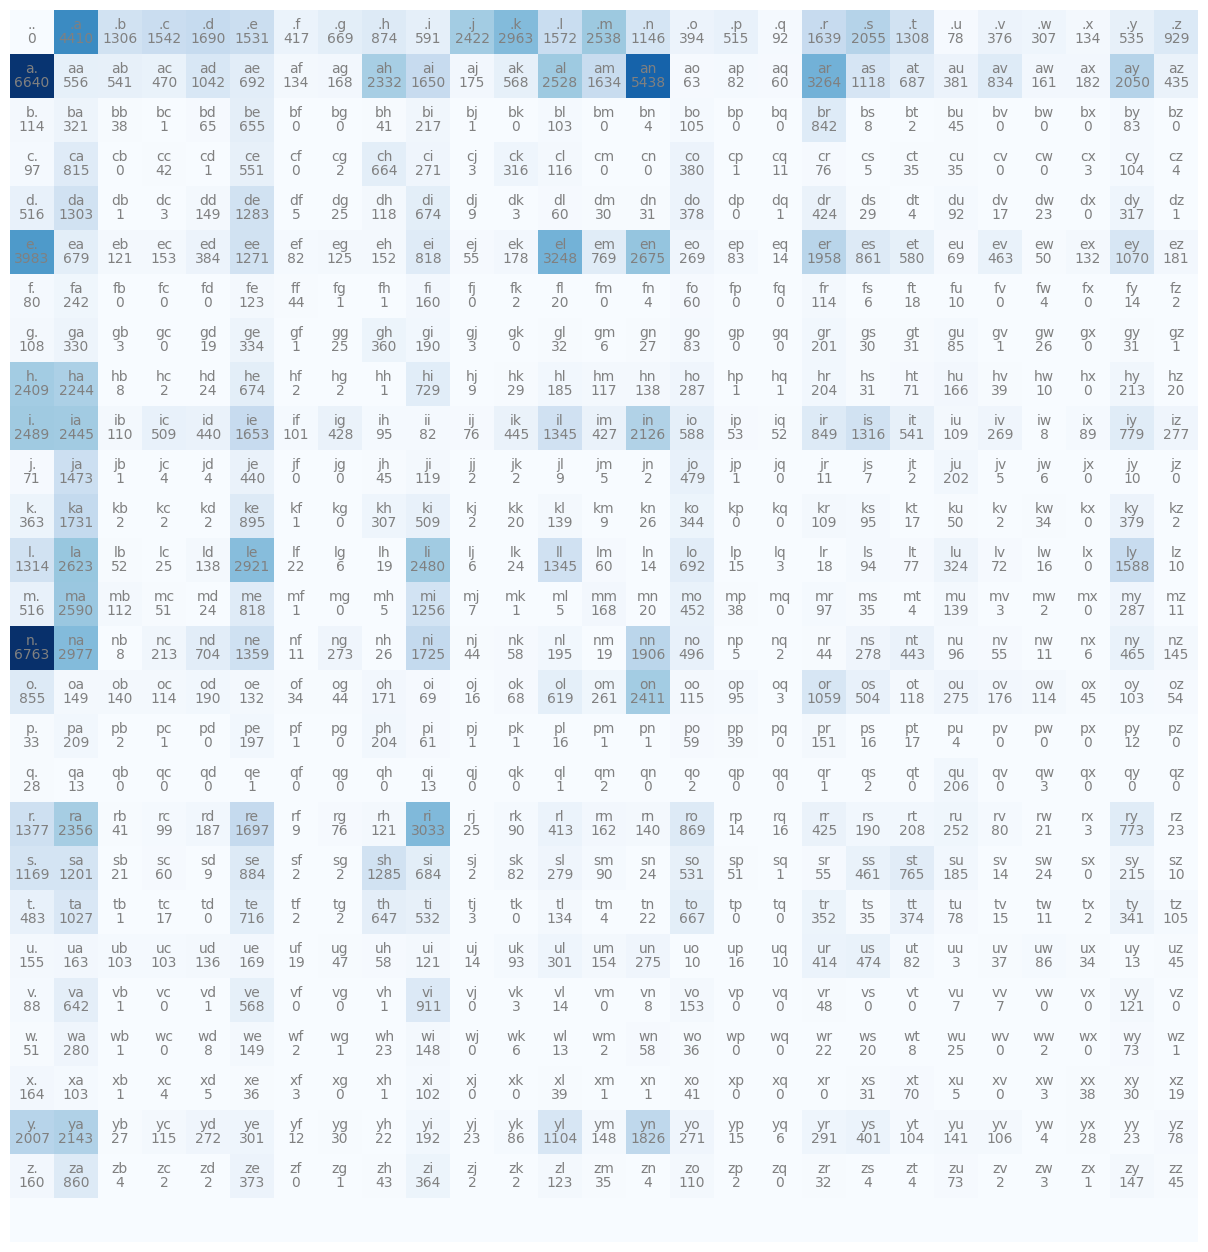

In [43]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis("off")

We can sample from the above graph to determine probabilities.

In [73]:
N[0, :]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [74]:
p = N[0].float()
p = p / p.sum() # Normalization
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

Use torch.multinomial with generators (deterministic) to sample from the probability

In [76]:
g = torch.Generator().manual_seed(2147483647)
idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[idx]

'c'

Now for the loop, we also need a matrix P of probabilities:

In [106]:
P = (N+1).float() # Add 1 to N for model smoothing, prevent 0 probabilities
P = P / P.sum(1, keepdim=True) # Summation of each row, keepdim keeps the reduced axis, but with size 1

In [107]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(5):
    out = []
    idx = 0
    while True:
        p = P[idx]
        
        #p = N[idx].float()
        #p = p / p.sum()

        # Uncomment the line below to see a normal distribution
        #p = torch.ones(27) / 27.0
        
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break
    
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


These names look bad because they are, bigram is not a good language model.
It's still better than a normal distribution though.

Now we want to quantify the model with the training loss - that is, the (avg) negative log likelihood.

In [109]:
log_likelihood = 0.0
cnt = 0
for w in ["andrewjq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1, idx2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        cnt += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

nll = -log_likelihood
print(f'Avg nll: {nll/cnt}')

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ew: 0.0025 -5.9939
wj: 0.0010 -6.8628
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331
Avg nll: 3.8692784309387207


Maximum likelihood estimation (MLE) demonstrates how likely our model would have guessed the sequence of characters which came up. Use log-likelihood to sum probabilities.